# 03 - Descriptive Evidence

Purpose:
- document gold's standalone behaviour before building an alarm;
- test whether static relationships are misleading;
- check whether gold has a simple return-level lead-lag relationship with the core conditioning variables;
- compare rolling-correlation windows before signal construction.

Core interpretation:
Gold should not be treated as a clean predictor of commodity stress. The stronger working premise is that abnormal gold behaviour and changing gold relationships may indicate cross-market regime instability.

## Reader Orientation

This notebook challenges the market intuition before any alarm is built. It asks whether Gold is fat-tailed, whether its static relationships are stable, and whether direct lead-lag evidence is strong. For a nowcasting dashboard, weak return-level prediction is acceptable; the key question is whether current Gold behaviour reveals abnormal cross-market conditions.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from scipy import stats

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step03"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

market_vars = pd.read_parquet(market_vars_path)

CORE_COLUMNS = ["r_Gold", "r_Brent", "r_DXY", "d_VIX", "d_US10Y"]
missing_cols = [col for col in CORE_COLUMNS if col not in market_vars.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns from Step 02 output: {missing_cols}")

market_vars = market_vars[CORE_COLUMNS].dropna().copy()
print("Loaded:", market_vars_path)
print("Shape:", market_vars.shape)
print("Date range:", market_vars.index.min(), "to", market_vars.index.max())
market_vars.tail()


Loaded: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\market_vars_core.parquet
Shape: (4090, 5)
Date range: 2010-01-05 00:00:00 to 2026-06-01 00:00:00


Ticker,r_Gold,r_Brent,r_DXY,d_VIX,d_US10Y
Date,,,,,
2026-05-26,-0.004567,-0.038997,-0.001511,0.309999,-0.065
2026-05-27,-0.011824,-0.054586,0.000403,-0.719999,-0.012
2026-05-28,0.011580,-0.006170,-0.001917,-0.550001,-0.026
2026-05-29,0.013510,-0.017873,-0.001111,-0.420000,-0.002
2026-06-01,-0.018881,0.031334,0.002928,0.730000,0.022


## Gold Return Distribution

This section checks whether gold returns look normal or fat-tailed. If gold itself has fat tails and skew, then simple normal assumptions are not enough for an operational warning framework.

In [4]:
gold = market_vars["r_Gold"].dropna()

summary = {
    "mean": gold.mean(),
    "std": gold.std(),
    "skew": gold.skew(),
    "excess_kurtosis": gold.kurtosis(),
    "q01": gold.quantile(0.01),
    "q05": gold.quantile(0.05),
    "q50": gold.quantile(0.50),
    "q95": gold.quantile(0.95),
    "q99": gold.quantile(0.99),
}

if stats is not None:
    jb = stats.jarque_bera(gold)
    summary["jarque_bera_stat"] = jb.statistic
    summary["jarque_bera_pvalue"] = jb.pvalue

gold_distribution_summary = pd.DataFrame([summary])
gold_distribution_summary


,mean,std,skew,excess_kurtosis,q01,q05,q50,q95,q99,jarque_bera_stat,jarque_bera_pvalue
0,0.000339,0.010748,-0.841538,8.767,-0.029307,-0.016651,0.000447,0.016613,0.027432,13544.297433,0.0


### Result Comment And Significance

The latest run shows gold daily log returns are negatively skewed, around -0.84, with high excess kurtosis, around 8.77. The Jarque-Bera p-value is effectively zero. This means gold is not well described by a normal return model, which supports using abnormality signals and stress testing rather than relying only on normal-market assumptions.

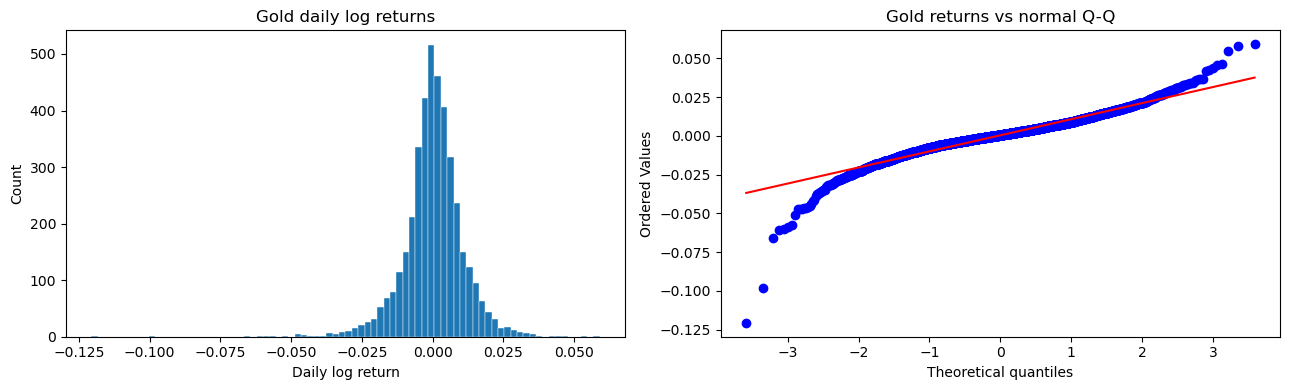

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gold, bins=80, edgecolor="white", linewidth=0.3)
axes[0].set_title("Gold daily log returns")
axes[0].set_xlabel("Daily log return")
axes[0].set_ylabel("Count")

if stats is not None:
    stats.probplot(gold, dist="norm", plot=axes[1])
    axes[1].set_title("Gold returns vs normal Q-Q")
else:
    gold.sort_values().reset_index(drop=True).plot(ax=axes[1])
    axes[1].set_title("Sorted gold returns")

plt.tight_layout()


## Gold Realized Volatility

Gold volatility is useful as one input, but it should not be the whole alarm. A regime can shift through relationships even if gold volatility does not spike.

,mean,std,min,max
gold_vol_10d,0.153538,0.076807,0.033695,0.771563
gold_vol_20d,0.157131,0.068183,0.050614,0.583978
gold_vol_30d,0.158553,0.063947,0.068563,0.500380


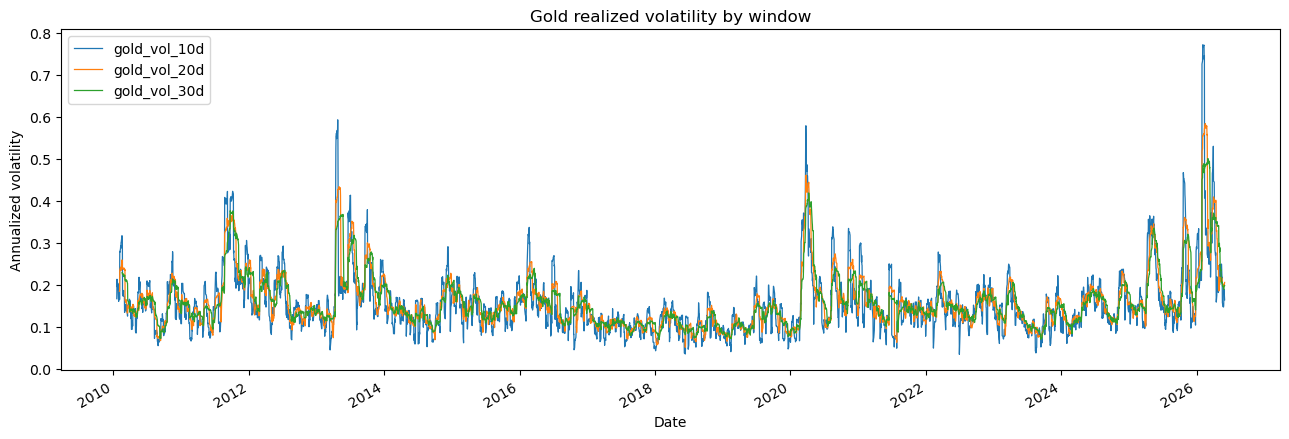

In [6]:
TRADING_DAYS = 252
VOL_WINDOWS = [10, 20, 30]

vol_table = pd.DataFrame(index=market_vars.index)
for window in VOL_WINDOWS:
    vol_table[f"gold_vol_{window}d"] = market_vars["r_Gold"].rolling(window).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(13, 4.5))
vol_table.plot(ax=ax, linewidth=0.9)
ax.set_title("Gold realized volatility by window")
ax.set_ylabel("Annualized volatility")
plt.tight_layout()

vol_summary = vol_table.agg(["mean", "std", "min", "max"]).T
vol_summary


### Result Comment And Significance

Gold realized volatility is useful but incomplete. A volatility spike can identify some stress periods, but the project should not rely on volatility alone because regime shifts can also appear as relationship breaks with DXY, VIX, yields, or Brent. This is why Step 04 includes return, volatility, residual, and relationship components.

## Static Correlation Baseline

Static correlations are only a baseline sanity check. They are not the final signal because the project is about relationship instability.

Ticker
r_DXY     -0.352449
d_US10Y   -0.226839
d_VIX     -0.013730
r_Brent    0.100682
Name: r_Gold, dtype: float64

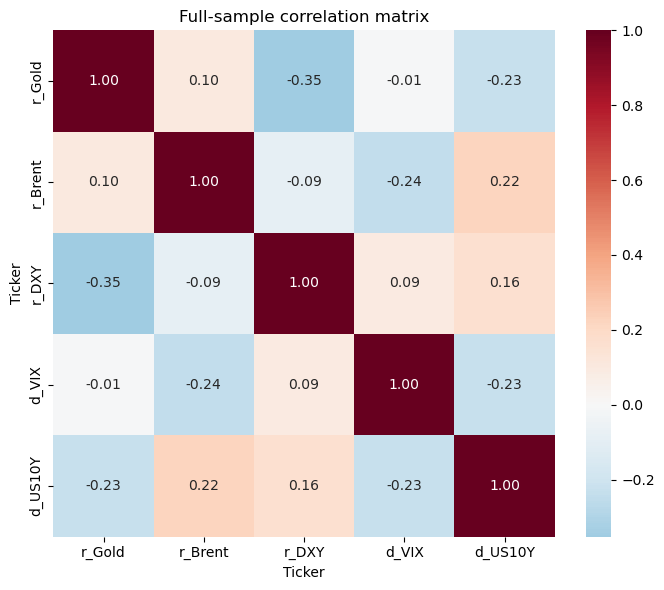

In [11]:
correlation_matrix = market_vars.corr()

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Full-sample correlation matrix")
plt.tight_layout()

correlation_matrix["r_Gold"].drop("r_Gold").sort_values()


### Result Comment And Significance

The latest static correlations are intuitive but limited: Gold is materially negative to DXY, around -0.35, negative to US10Y changes, around -0.23, only mildly positive to Brent, around 0.10, and almost flat to VIX changes. The near-zero Gold-VIX full-sample relationship is important: it does not mean VIX is irrelevant; it means static averages can hide changing regimes.

## Return-Level Lead-Lag Check

This deliberately challenges the simple version of the thesis. If gold returns do not show a clean direct lead-lag relationship, the final claim should focus on relationship instability rather than direct return prediction.

### How To Read This For Nowcasting

If this test is weak, the project is not invalidated. It simply means the dashboard should not be sold as a return-forecasting model. The nowcasting claim is different: Gold can still be useful if abnormal current relationships signal that the risk environment has changed.

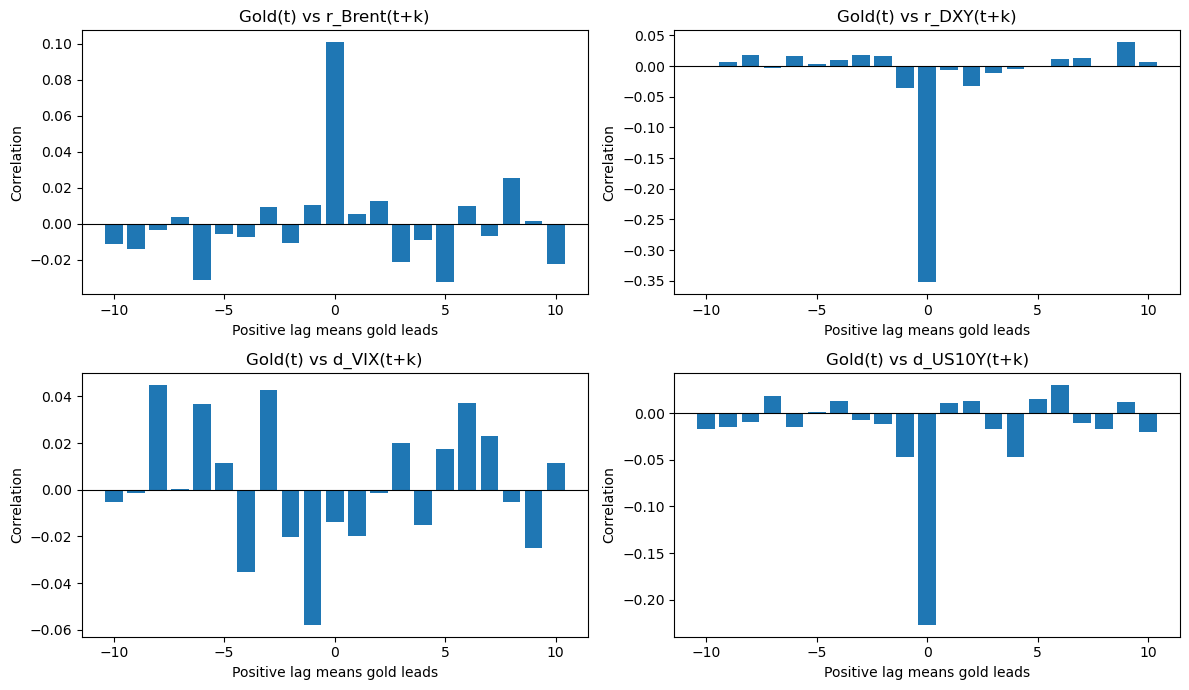

In [8]:
def cross_correlation(x: pd.Series, y: pd.Series, max_lag: int = 10) -> pd.DataFrame:
    rows = []
    for lag in range(-max_lag, max_lag + 1):
        rows.append({"lag": lag, "corr": x.corr(y.shift(-lag))})
    return pd.DataFrame(rows)

conditioning_cols = ["r_Brent", "r_DXY", "d_VIX", "d_US10Y"]
ccf_tables = []
for col in conditioning_cols:
    table = cross_correlation(market_vars["r_Gold"], market_vars[col], max_lag=10)
    table["target"] = col
    ccf_tables.append(table)

ccf = pd.concat(ccf_tables, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flat, conditioning_cols):
    table = ccf.loc[ccf["target"] == col]
    ax.bar(table["lag"], table["corr"])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Gold(t) vs {col}(t+k)")
    ax.set_xlabel("Positive lag means gold leads")
    ax.set_ylabel("Correlation")
plt.tight_layout()


### Why This Challenges The Thesis

This is a direct lead-lag check. If Gold(t) does not show strong correlation with Brent, DXY, VIX, or US10Y at future lags, then the project should not claim that gold returns mechanically predict commodity stress. The better claim is that gold relationship instability may provide an escalation signal.

## Rolling Relationship Evidence

This section compares 20-day, 60-day, and 120-day rolling correlations. The intended decision rule is:
- 20-day: responsive but noisy;
- 60-day: primary detector candidate;
- 120-day: slower context/baseline.

,window,target,mean,std,min,max
0,20,r_Brent,0.128453,0.303022,-0.826557,0.874569
1,20,r_DXY,-0.395294,0.278463,-0.899296,0.668521
2,20,d_VIX,-0.005987,0.308991,-0.788568,0.757903
3,20,d_US10Y,-0.269440,0.297766,-0.888668,0.722588
4,60,r_Brent,0.140713,0.200168,-0.411465,0.681530
5,60,r_DXY,-0.387768,0.206839,-0.783571,0.324026
6,60,d_VIX,0.009229,0.225898,-0.627795,0.585529
7,60,d_US10Y,-0.270771,0.223932,-0.724830,0.371906
8,120,r_Brent,0.140125,0.159976,-0.253251,0.559141
9,120,r_DXY,-0.388511,0.158695,-0.731736,0.117680


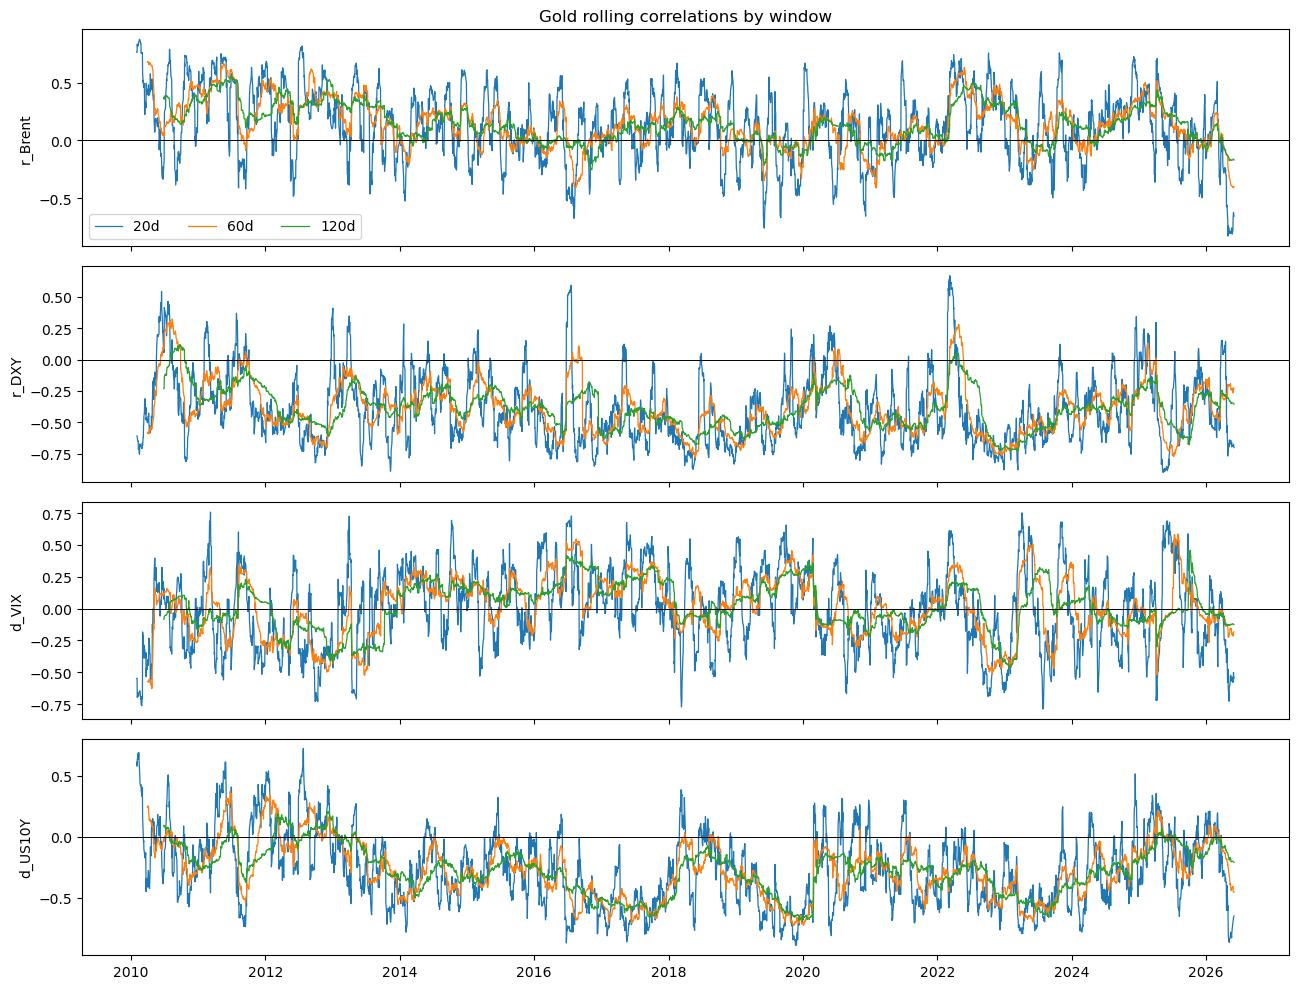

In [9]:
ROLLING_WINDOWS = [20, 60, 120]
rolling_corr = {}

for window in ROLLING_WINDOWS:
    rolling_corr[window] = pd.DataFrame({
        col: market_vars["r_Gold"].rolling(window).corr(market_vars[col])
        for col in conditioning_cols
    })

fig, axes = plt.subplots(len(conditioning_cols), 1, figsize=(13, 10), sharex=True)
for ax, col in zip(axes, conditioning_cols):
    for window in ROLLING_WINDOWS:
        ax.plot(rolling_corr[window].index, rolling_corr[window][col], label=f"{window}d", linewidth=0.9)
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_ylabel(col)
axes[0].legend(ncol=3)
axes[0].set_title("Gold rolling correlations by window")
plt.tight_layout()

rolling_corr_summary = []
for window, table in rolling_corr.items():
    for col in table.columns:
        rolling_corr_summary.append({
            "window": window,
            "target": col,
            "mean": table[col].mean(),
            "std": table[col].std(),
            "min": table[col].min(),
            "max": table[col].max(),
        })
rolling_corr_summary = pd.DataFrame(rolling_corr_summary)
rolling_corr_summary


### Result Comment And Significance

The rolling-correlation summaries support using a 60-day relationship window as the main detector. The 20-day window has wider swings and more noise; the 120-day window is smoother but slower. In the latest run, 60-day Gold-VIX correlation ranges roughly from -0.63 to +0.59, showing that a static Gold-VIX correlation near zero hides meaningful regime variation.

## Step 03 Working Takeaways

- Static correlations are useful only as a baseline.
- Gold volatility should be treated as one component, not a standalone alarm.
- If direct return-level lead-lag is weak, the thesis should be framed around gold relationship instability and operational escalation.
- The 60-day rolling relationship window is the main candidate for Step 04 signal construction.

In [10]:
gold_distribution_summary.to_csv(OUTPUT_DIR / "gold_distribution_summary.csv", index=False)
vol_summary.to_csv(OUTPUT_DIR / "gold_volatility_summary.csv")
correlation_matrix.to_csv(OUTPUT_DIR / "static_correlation_matrix.csv")
ccf.to_csv(OUTPUT_DIR / "gold_cross_correlation.csv", index=False)
rolling_corr_summary.to_csv(OUTPUT_DIR / "rolling_correlation_window_summary.csv", index=False)

print("Saved Step 03 descriptive evidence outputs to:", OUTPUT_DIR)


Saved Step 03 descriptive evidence outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step03
